In [1]:
# First let's import the relevant packages
import numpy as np
from scipy.special import spherical_jn, spherical_yn , hankel1,lpmv,jn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.special as sc
import math
from matplotlib.colors import LogNorm

**Bellow we have the general Electrid Field that will be used**


# Mie Coefficients

In [2]:
def MieCoefCond2(x, n):
    """
    Compute the Mie scattering coefficients for a perfectly conducting sphere.

    This function calculates the Mie coefficients (a_n and b_n) for 
    a perfectly electrically conducting (PEC) material using spherical 
    Bessel functions of the first kind and spherical Hankel functions 
    of the first kind.

    Args:
        x (float or array-like): Size parameter (k * r), where k is the 
            wavenumber of the incident wave and r is the sphere radius. 
            Can be a scalar or a NumPy array.
        n (int): Order of the Mie coefficient to compute (n ≥ 1).

    Returns:
        tuple of complex:
            - a (complex): Mie coefficient a_n.
            - b (complex): Mie coefficient b_n.

    Notes:
        - Assumes the sphere is a perfect electric conductor (PEC).
        - Uses spherical Bessel functions (`spherical_jn`) and spherical 
          Hankel functions (`hankel1`).
        - The expressions follow standard Mie theory formulations for 
          conductive spheres.
    """
    # calculate the functions used in the calculations
    jn = spherical_jn(n, x)
    jn1 = spherical_jn(n+1,x)
    jn_1 = spherical_jn(n-1,x)
    
    hankeln = np.sqrt(np.pi/(2*x))*hankel1(n+1/2,x)
    hankeln1 = np.sqrt(np.pi/(2*x))*hankel1(n+1+1/2,x)
    hankeln_1 = np.sqrt(np.pi/(2*x))*hankel1(n-1+1/2,x)
    
    a = -(jn + x *1/2* (  x* (jn_1-jn1) + jn ))/(hankeln + x  *1/2* ( x*(hankeln_1-hankeln1) + hankeln))
    b = - jn/hankeln  
    
    return a, b

# Example usage
x = 1.0
n = 1
GTM = 2.0
GTE = 3.0


a, b = MieCoefCond2(x, n)
print("a:", a)
print("b:", b)

a: (-0.7080734182735715-0.45464871341284097j)
b: (-0.045351286587159194-0.2080734182735714j)


In python we do not have a package that calculate the spherical hankel functions of the first kind, so parting from the hankel function we can write them
\begin{equation}
    h_n^{(1)}(z) = \sqrt{ \frac{\pi}{2z}}H_{n+1/2}^{(1)}(z)
\end{equation}


In [3]:
def MieCoef(x, M, n):
    """
    Compute the general Mie scattering coefficients (a_n, b_n).

    This function calculates the Mie coefficients for a spherical 
    particle with relative refractive index M embedded in a medium. 
    The formulation is based on spherical Bessel functions of the 
    first kind and spherical Hankel functions of the first kind, 
    expressed in terms of Riccati–Bessel functions.

    Args:
        x (float): Size parameter of the sphere (x = k * r), where 
            k is the wavenumber in the surrounding medium and r is 
            the sphere radius.
        M (float or complex): Relative refractive index of the sphere 
            (n_particle / n_medium).
        n (int): Order of the coefficient to compute (n ≥ 1).

    Returns:
        tuple of complex:
            - a_n (complex): Electric-type Mie coefficient.
            - b_n (complex): Magnetic-type Mie coefficient.

    Notes:
        - a_n and b_n correspond to the scattering coefficients defined 
          in standard Mie theory.
        - This implementation uses Riccati–Bessel functions:
              ψ_n(z) = z * j_n(z)
              ζ_n(z) = z * h_n^(1)(z)
          and their derivatives with respect to z.
        - Coefficients c_n and d_n (related to internal fields) are 
          commented out but can be added if needed.
    """
    # Computing spherical Bessel functions for n and M*n
    j_n_x = spherical_jn(n, x)
    j_n_Mx = spherical_jn(n, M*x)

    # Computing Riccati-Bessel functions
    psi_n_x = x * j_n_x
    zeta_n_x = x * np.sqrt(np.pi/(2*x))*hankel1(n+1/2,x)

    psi_n_Mx = M * x * j_n_Mx
    zeta_n_Mx = M * x * np.sqrt(np.pi/(2*M*x))*hankel1(n+1/2,M*x)

    # Computing Riccati-Bessel function
    psi_n_x_prime = 1/2* (  x* (spherical_jn(n-1,x)-spherical_jn(n+1,x)) + spherical_jn(n,x) ) 
    
    zeta_n_x_prime = 1/2* np.sqrt(np.pi/(2*x))*(  x* (hankel1(n+1/2-1,x)-hankel1(n+1/2+1,x)) + hankel1(n+1/2,x) )

    psi_n_Mx_prime = 1/2* (  M*x* (spherical_jn(n-1,M*x)-spherical_jn(n+1,M*x)) + spherical_jn(n,M*x) ) 
    
    zeta_n_Mx_prime= 1/2* np.sqrt(np.pi/(2*M*x))*(  x* (hankel1(n+1/2-1,M*x)-hankel1(n+1/2+1,M*x)) + hankel1(n+1/2,M*x) )

    # Calculating coefficients a_n, b_n, c_n, d_n
    a_n = (M * psi_n_Mx * psi_n_x_prime - psi_n_Mx_prime * psi_n_x) / (psi_n_Mx_prime * zeta_n_x - M * psi_n_Mx * zeta_n_x_prime)
    b_n = (M * psi_n_Mx_prime * psi_n_x - psi_n_Mx * psi_n_x_prime) / (psi_n_Mx * zeta_n_x_prime - M * psi_n_Mx_prime * zeta_n_x)
    
    #c_n = (psi_n_x * zeta_n_x_prime - psi_n_x_prime * zeta_n_x) / (psi_n_Mx_prime * zeta_n_x - M * psi_n_Mx * zeta_n_x_prime)
    #d_n = (psi_n_x_prime * zeta_n_x - psi_n_x * zeta_n_x_prime) / (psi_n_Mx * zeta_n_x_prime - M * psi_n_Mx_prime * zeta_n_x)

    return a_n, b_n

# Test the function with scalar inputs
wavelength = 1
radius = 5
k = 2 * np.pi / wavelength
x_value = k * radius
print(MieCoef(x_value, 155/133, 30))


(np.complex128(-0.505726836616118-0.49996720226667923j), np.complex128(-0.5041828204976252-0.49998250370656255j))


In [4]:
def E1_SCATnm(n,m, a_n, b_n, k, x, y, z):
    """
    Compute the scattered electric field vector in Cartesian coordinates 
    for a given multipole order n using Mie theory.

    Args:
        n (int): Multipole order of the expansion.
        a_n (complex): Mie coefficient 'a_n' associated with electric multipoles.
        b_n (complex): Mie coefficient 'b_n' associated with magnetic multipoles.
        k (float): Wavenumber of the incident light (2π/λ).
        x (float or np.ndarray): x-coordinate(s) where the field is evaluated.
        y (float or np.ndarray): y-coordinate(s) where the field is evaluated.
        z (float or np.ndarray): z-coordinate(s) where the field is evaluated.

    Returns:
        np.ndarray: A complex-valued array of shape (3, ...) containing the 
        scattered electric field components [E_x, E_y, E_z] in Cartesian coordinates.

    Notes:
        - Internally, the function converts (x, y, z) into spherical coordinates 
          (r, θ, φ) to evaluate the field, then transforms the result back to Cartesian form.
        - Associated Legendre polynomials and spherical Hankel functions are used 
          to compute the multipole contributions.
        - Special handling is applied for θ → 0 to avoid singularities, setting 
          limiting values for derivatives of Legendre polynomials.
        - The output is suitable for constructing field maps in real space.    
    """
    r = np.sqrt(x**2 + y**2 + z**2)
    phi = np.sign(y) * np.arccos(x/np.sqrt(x**2+y**2))
    theta = np.arccos(z / r)

    kr = k * r
    
    sph_hankel_n1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n+1 + 1/2,kr)
    sph_hankel_n = np.sqrt(np.pi/(2*kr))*sc.hankel1(n + 1/2,kr)
    sph_hankel_n_1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n-1 + 1/2,kr)

    dhn = 1/2 * ( k * sph_hankel_n_1 -  1/(r) *(sph_hankel_n) - k*sph_hankel_n1 )

    fac = math.factorial(n-abs(m))/math.factorial(n+abs(m))
    pre = 1j / np.sqrt(n * (n + 1)) * np.sqrt( (2 * n + 1) / (4 * np.pi) * fac )*  np.exp(1j*m*phi)/(np.sin(theta))

    if m>=0:
        P_nm=lpmv(m,n,np.cos(theta))
        P_nm1=lpmv(m,n+1,np.cos(theta))
        P_nm2=lpmv(m,n+2,np.cos(theta))

    if m<0:
        #m = abs(m)
        P_nm=lpmv(abs(m),n,np.cos(theta))*(-1)**(m) 
        P_nm1=lpmv(abs(m),n+1,np.cos(theta))*(-1)**(m) 
        P_nm2=lpmv(abs(m),n+2,np.cos(theta))*(-1)**(m) 

        


    dPnm = ( (n+1)*np.cos(theta) * P_nm + (-1+abs(m)-n)*P_nm1  )

    term1 = (2 - 2*m**2 + 3*n + n**2 + n*(n+1)* np.cos(2*theta) )*P_nm
    term2 = 2* (abs(m)-n-1) * ( ( 3 +2*n) *np.cos(theta)*P_nm1 + (-2 + abs(m) -n) * P_nm2 )
    dPnm1 = ( term1 + term2 )

    # --------
    

    E_0 = [ 0 *dPnm,           
            -dPnm       ,
            1j*m*P_nm 
    ]
    E_r0 = E_0[0]
    E_theta0 = E_0[1] * dhn * pre
    E_phi0 = E_0[2] * dhn * pre
    E_0 = np.array([E_r0 , E_theta0,E_phi0])


    E_1 = [ -1/(2*np.sin(theta)) * dPnm1 ,
            -dPnm,
           1j*m*P_nm  
    ]
    E_r1 = E_1[0] * 1/(r) * sph_hankel_n * pre
    E_theta1 = E_1[1] * 1/(r) * sph_hankel_n * pre
    E_phi1 = E_1[2] * 1/(r) * sph_hankel_n * pre
    E_1 = np.array([E_r1,E_theta1,E_phi1])
    
    E1= 1j*a_n/k * (E_0 + E_1)
       
    #==================
    # Now the term with bnm which only has the X_nm(theta,phi)


    X_nm = [ 0*dPnm ,
        1j * m * P_nm,
        dPnm ]#dPn ]


    E_r = X_nm[0]

    E_theta = b_n * sph_hankel_n*X_nm[1] * pre
    
    E_phi =  b_n * sph_hankel_n*X_nm[2] * pre
    
    E2 =  np.array([E_r,E_theta, E_phi])
    Et = E1+E2

    term_r = Et[0]
    term_the = Et[1]
    term_phi = Et[2]

    return (np.array([term_r * np.cos(phi) * np.sin(theta), term_r * np.sin(theta) * np.sin(phi), term_r * np.cos(theta)]) +
                     np.array([term_the * np.cos(phi) * np.cos(theta), term_the * np.cos(theta) * np.sin(phi), -term_the * np.sin(theta)]) +
                     np.array([-term_phi * np.sin(phi), term_phi * np.cos(phi), np.zeros_like(r)]))


In [5]:
def H1_SCATnm(n, m, a_n, b_n, k, x, y, z, Z=1):
    r = np.sqrt(x**2 + y**2 + z**2)
    phi = np.sign(y) * np.arccos(x/np.sqrt(x**2+y**2))
    theta = np.arccos(z / r)

    kr = k * r
    
    sph_hankel_n1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n+1 + 1/2,kr)
    sph_hankel_n = np.sqrt(np.pi/(2*kr))*sc.hankel1(n + 1/2,kr)
    sph_hankel_n_1 = np.sqrt(np.pi/(2*kr))*sc.hankel1(n-1 + 1/2,kr)

    dhn = 1/2 * ( k * sph_hankel_n_1 -  1/(r) *(sph_hankel_n) - k*sph_hankel_n1 )

    fac = math.factorial(n-abs(m))/math.factorial(n+abs(m))
    pre = 1j / np.sqrt(n * (n + 1)) * np.sqrt((2 * n + 1) / (4 * np.pi) * fac) * np.exp(1j*m*phi)/(np.sin(theta))

    # Legendre
    if m >= 0:
        P_nm = lpmv(m, n, np.cos(theta))
        P_nm1 = lpmv(m, n+1, np.cos(theta))
        P_nm2 = lpmv(m, n+2, np.cos(theta))
    else:
        P_nm = lpmv(abs(m), n, np.cos(theta))*(-1)**(m)
        P_nm1 = lpmv(abs(m), n+1, np.cos(theta))*(-1)**(m)
        P_nm2 = lpmv(abs(m), n+2, np.cos(theta))*(-1)**(m)

    dPnm = ((n+1)*np.cos(theta)*P_nm + (-1+abs(m)-n)*P_nm1)

    term1 = (2 - 2*m**2 + 3*n + n**2 + n*(n+1)*np.cos(2*theta))*P_nm
    term2 = 2*(abs(m)-n-1)*((3+2*n)*np.cos(theta)*P_nm1 + (-2+abs(m)-n)*P_nm2)
    dPnm1 = term1 + term2

    # =========================
    # CURL TERM → now uses b_n instead of a_n

    H_0 = [0*dPnm,
           -dPnm,
           1j*m*P_nm]

    H_r0 = H_0[0]
    H_theta0 = H_0[1] * dhn * pre
    H_phi0 = H_0[2] * dhn * pre
    H_0 = np.array([H_r0, H_theta0, H_phi0])

    H_1 = [-1/(2*np.sin(theta)) * dPnm1,
           -dPnm,
           1j*m*P_nm]

    H_r1 = H_1[0] * 1/r * sph_hankel_n * pre
    H_theta1 = H_1[1] * 1/r * sph_hankel_n * pre
    H_phi1 = H_1[2] * 1/r * sph_hankel_n * pre
    H_1 = np.array([H_r1, H_theta1, H_phi1])

    # SIGN CHANGE + swap a_n → b_n
    Hcurl = -1j * b_n / k * (H_0 + H_1)

    # =========================
    # DIRECT TERM → now uses a_n instead of b_n

    X_nm = [0*dPnm,
            1j * m * P_nm,
            dPnm]

    H_r = X_nm[0]
    H_theta = a_n * sph_hankel_n * X_nm[1] * pre
    H_phi = a_n * sph_hankel_n * X_nm[2] * pre

    Hdir = np.array([H_r, H_theta, H_phi])

    Ht = Hcurl + Hdir

    term_r = Ht[0]
    term_the = Ht[1]
    term_phi = Ht[2]

    # Cartesian projection + 1/Z
    return (1/Z) * (
        np.array([
            term_r * np.cos(phi) * np.sin(theta),
            term_r * np.sin(theta) * np.sin(phi),
            term_r * np.cos(theta)
        ]) +
        np.array([
            term_the * np.cos(phi) * np.cos(theta),
            term_the * np.cos(theta) * np.sin(phi),
            -term_the * np.sin(theta)
        ]) +
        np.array([
            -term_phi * np.sin(phi),
            term_phi * np.cos(phi),
            np.zeros_like(r)
        ])
    )

In [7]:
# Iniciate the Scattered fields
E01_sca = 0
H01_sca = 0

N = 1034
wavelength = 0.65
radius = 100
k = 2 * np.pi / wavelength
x_value = k * radius

n = 450
x = 0#np.linspace(-1.2*radius,1.2*radius,n)
y = np.linspace(-1.2*radius,1.2*radius,n)
z = 1000

for i in range(1, N):
    a_n, b_n = MieCoefCond2(x_value, i)

    Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)

    GnmTE = Gn
    Gn_1TE = -Gn
    Gn1TM = -1j*Gn
    Gn_1TM = -1j*Gn

    if np.isnan(np.abs(a_n)) or np.isnan(np.abs(b_n)):
        print('Limit Achived')
        break

    # -------------------
    # Electric field
    E01_sca += E1_SCATnm(i,  1, a_n*Gn1TM, b_n*GnmTE, k, x, y, z)
    E01_sca += E1_SCATnm(i, -1, a_n*Gn_1TM, b_n*Gn_1TE, k, x, y, z)

    # -------------------
    # Magnetic field (same coefficients!)
    H01_sca += H1_SCATnm(i,  1, a_n*Gn1TM, b_n*GnmTE, k, x, y, z, Z=1)
    H01_sca += H1_SCATnm(i, -1, a_n*Gn_1TM, b_n*Gn_1TE, k, x, y, z, Z=1)

In [9]:
Z=1
EE_inc =  np.array([np.ones(n)*0, np.ones(n)*np.exp(1j*k*z), np.ones(n)*0])  # y-polarized plane wave
H_inc = np.array([
    -np.ones(n)*np.exp(1j*k*z)/Z,
    0*np.ones(n),
    0*np.ones(n)
])
E_tot = EE_inc + E01_sca
H_tot = H_inc + H01_sca

In [10]:
I_E = np.real(np.sum(E_tot * np.conj(E_tot), axis=0))
S = 0.5 * np.real(np.cross(E_tot, np.conj(H_tot), axis=0))
I_S = np.linalg.norm(S, axis=0)

In [11]:
I_E /= np.max(I_E)
I_S /= np.max(I_S)

error = np.abs(I_E - I_S)

print("Mean error:", np.mean(error))
print("Max error:", np.max(error))

Mean error: 0.0002703654748531386
Max error: 0.005040436463014868


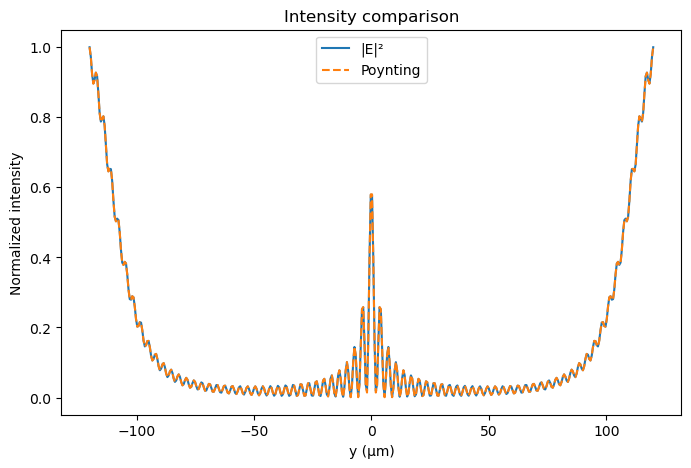

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(y, I_E, label='|E|²')
plt.plot(y, I_S, '--', label='Poynting')
plt.legend()
plt.xlabel('y (µm)')
plt.ylabel('Normalized intensity')
plt.title('Intensity comparison')
plt.show()

Compare throught multiple distances

In [6]:
# -----------------------
# Constants
N_terms = 1034
wavelength = 0.65
radius = 100
k = 2 * np.pi / wavelength
x_value = k * radius

n_points = 450
x = 0
y = np.linspace(-1.2*radius, 1.2*radius, n_points)

Z_imp = 1

# -----------------------
# z range (from R to 100R)
z_values = np.linspace(radius, 100*radius, 20)

mean_errors = []
max_errors = []

# -----------------------
# Precompute Mie coefficients (huge speedup)
a_list = []
b_list = []

for i in range(1, N_terms):
    a_n, b_n = MieCoefCond2(x_value, i)
    
    if np.isnan(np.abs(a_n)) or np.isnan(np.abs(b_n)):
        print("Limit Achieved at n =", i)
        break
        
    a_list.append(a_n)
    b_list.append(b_n)

N_eff = len(a_list)
print("Using", N_eff, "terms")

# -----------------------
# Loop over z
curves_E = []
curves_S = []
z_selected = []
for z in z_values:

    E01_sca = 0
    H01_sca = 0

    for i in range(1, N_eff+1):
        a_n = a_list[i-1]
        b_n = b_list[i-1]

        Gn = -1 * 1j**(i+1) * np.sqrt((2*i +1)*np.pi)

        GnmTE = Gn
        Gn_1TE = -Gn
        Gn1TM = -1j*Gn
        Gn_1TM = -1j*Gn

        # Electric field
        E01_sca += E1_SCATnm(i,  1, a_n*Gn1TM, b_n*GnmTE, k, x, y, z)
        E01_sca += E1_SCATnm(i, -1, a_n*Gn_1TM, b_n*Gn_1TE, k, x, y, z)

        # Magnetic field
        H01_sca += H1_SCATnm(i,  1, a_n*Gn1TM, b_n*GnmTE, k, x, y, z, Z_imp)
        H01_sca += H1_SCATnm(i, -1, a_n*Gn_1TM, b_n*Gn_1TE, k, x, y, z, Z_imp)

    # -----------------------
    # Incident fields
    EE_inc = np.array([
        np.zeros(n_points),
        np.ones(n_points)*np.exp(1j*k*z),
        np.zeros(n_points)
    ])

    H_inc = np.array([
        -np.ones(n_points)*np.exp(1j*k*z)/Z_imp,
        np.zeros(n_points),
        np.zeros(n_points)
    ])

    # -----------------------
    # Total fields
    E_tot = EE_inc + E01_sca
    H_tot = H_inc + H01_sca

    # -----------------------
    # Intensities
    I_E = np.real(np.sum(E_tot * np.conj(E_tot), axis=0))

    S = 0.5 * np.real(np.cross(E_tot, np.conj(H_tot), axis=0))
    I_S = np.linalg.norm(S, axis=0)

    # Normalize
    I_E /= np.max(I_E)
    I_S /= np.max(I_S)

    curves_E.append(I_E)
    curves_S.append(I_S)
    z_selected.append(z)

    # Error
    error = np.abs(I_E - I_S)

    mean_errors.append(np.mean(error))
    max_errors.append(np.max(error))

    print(f"z = {z:.1f} | mean error = {np.mean(error):.4e}, max error = {np.max(error):.4e}")

Using 1033 terms
z = 100.0 | mean error = 2.0179e-04, max error = 2.6151e-03
z = 621.1 | mean error = 4.5714e-04, max error = 1.2832e-02
z = 1142.1 | mean error = 2.3444e-04, max error = 4.0371e-03
z = 1663.2 | mean error = 1.5330e-04, max error = 2.0375e-03
z = 2184.2 | mean error = 1.0871e-04, max error = 1.1843e-03
z = 2705.3 | mean error = 9.2155e-05, max error = 8.0500e-04
z = 3226.3 | mean error = 6.6138e-05, max error = 5.3475e-04
z = 3747.4 | mean error = 5.1817e-05, max error = 3.8106e-04
z = 4268.4 | mean error = 4.1468e-05, max error = 2.8441e-04
z = 4789.5 | mean error = 3.4522e-05, max error = 2.1970e-04
z = 5310.5 | mean error = 2.8864e-05, max error = 1.7438e-04
z = 5831.6 | mean error = 2.4309e-05, max error = 1.4192e-04
z = 6352.6 | mean error = 2.2046e-05, max error = 1.1761e-04
z = 6873.7 | mean error = 1.8797e-05, max error = 9.8888e-05
z = 7394.7 | mean error = 1.7136e-05, max error = 8.4314e-05
z = 7915.8 | mean error = 1.5579e-05, max error = 7.2732e-05
z = 8436.

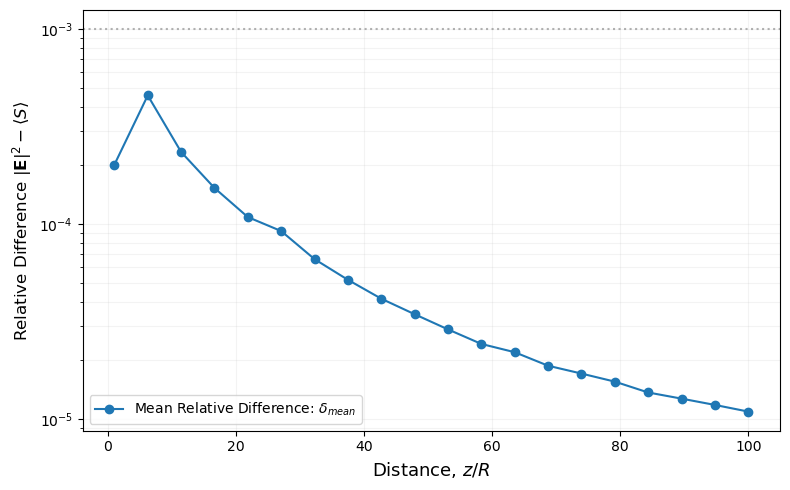

In [12]:
plt.figure(figsize=(8, 5))

# Use descriptive labels that specify what is being compared
plt.plot(z_values/radius, mean_errors, 'o-', color='#1f77b4', linewidth=1.5, 
         label=r'Mean Relative Difference: $\delta_{mean}$')

#plt.plot(z_values/radius, max_errors, 's--', color='#d62728', linewidth=1.5, 
#         label=r'Max Relative Difference: $\delta_{max}$')

# Use a log scale to show the precision of the calculation
plt.yscale('log')

# Mathematically precise axis names
plt.xlabel(r'Distance, $z/R$', fontsize=13)
plt.ylabel(r'Relative Difference $|\mathbf{E}|^2 - \langle S \rangle$', fontsize=12)

# Add a horizontal line at 0.1% to show the "Acceptable threshold"
plt.axhline(y=1e-3, color='gray', linestyle=':', alpha=0.6)

plt.legend(loc='best', frameon=True, fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.15)

# High DPI for the manuscript
plt.tight_layout()
plt.savefig('Error_perz.pdf', dpi=300)
plt.show()

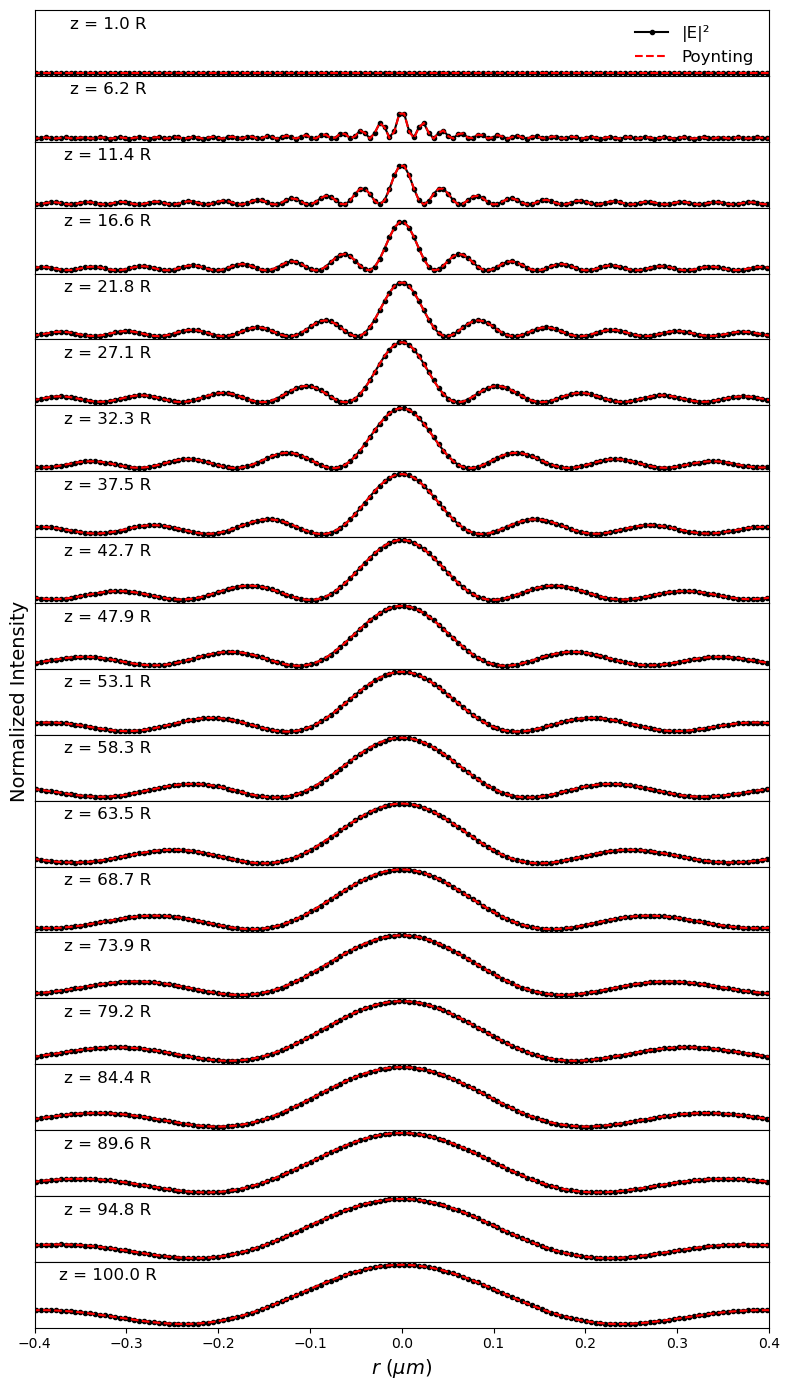

In [33]:
# Figure + grid
fig = plt.figure(figsize=(8, 14))
gs = gridspec.GridSpec(len(z_selected), 1, hspace=0.0)

for u in range(len(z_selected)):
    ax = fig.add_subplot(gs[u, 0])

    z_val = z_selected[u]

    # Plot |E|^2
    ax.plot(y/radius, curves_E[u], '.-', color='black', label='|E|²')

    # Plot Poynting
    ax.plot(y/radius, curves_S[u], '--', color='red', label='Poynting')

    # Limits
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(-0.05, 1.05)

    # Remove y ticks for cleaner look
    ax.set_yticks([])

    # Annotation (same style you used)
    ax.annotate(f'z = {z_val/radius:.1f} R',
                xy=(0.1, 0.9), xycoords='axes fraction',
                ha='center', va='top',
                fontsize=12)

    # Show legend only once
    if u == 0:
        ax.legend(loc='upper right', frameon=False,fontsize=12)

    # Remove x-axis except bottom
    if u < len(z_selected) - 1:
        ax.set_xticks([])
        ax.xaxis.set_visible(False)

# Shared labels
fig.axes[-1].set_xlabel(r'$r~(\mu m)$', fontsize=14)
fig.axes[len(z_selected)//2].set_ylabel('Normalized Intensity', fontsize=14)

plt.tight_layout()
plt.savefig('ProfileComp_PvsE.pdf',dpi=100)